# M7 · The Full Ranking Pipeline — CTR + VTR + LTR + History (for a New Student)

**Companion to lesson M7. Assumes no prior ML.** The other M7 notebook built one model
for one thing (clicks). Real ad rankers predict **several things at once** and use your
**history**. This notebook builds that shape, end to end, in tiny explained steps.

### First, the vocabulary (three "p" numbers a ranker predicts)
For each ad shown to a person, the model predicts three probabilities:
- **CTR** — *Click-Through Rate*: chance they **click** the ad.
- **VTR** — *View-Through Rate*: chance they **watch/view** it (mostly for video ads).
- **LTR** — *Lead-Through Rate*: chance it leads to a **conversion/lead** (a signup, a form).

And **history**: what this person did *before* — e.g. how much they engaged with *similar*
ads in the past. History is one of the strongest signals in real systems, so we'll include
it and then **prove** it helps.

### The big idea: one model, three heads (multi-task)
Instead of training three separate models, we train **one** network with a shared body and
**three output "heads"** (one per outcome). Sharing lets the three tasks help each other
and is far cheaper to serve. This is the **shared-bottom** design from lesson M7.3.

Run each cell with **Shift+Enter**; read the note above it first.

## Step 1 · Set up and create the *static* features

An **example** = one ad shown to one person (an *impression*). Static features are things
about the ad and the slot that don't depend on the person's past:
- `relevance` (0–1), `ad_quality` (0–1), `price` (0–1, the advertiser's price tier),
- `position` (1–10, slot on the page), `is_video` (1 = video ad).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"
HEADS = ["CTR", "VTR", "LTR"]; HEAD_COLORS = [BLUE, GREEN, PURPLE]

rng = np.random.default_rng(7)
N = 8000

relevance  = rng.uniform(0, 1, N)
ad_quality = rng.uniform(0, 1, N)
price      = rng.uniform(0, 1, N)
position   = rng.integers(1, 11, N)
is_video   = rng.integers(0, 2, N)
print("created", N, "impressions with 5 static features")
print("share of video ads:", round(is_video.mean(), 2))

created 8000 impressions with 5 static features
share of video ads: 0.5


## Step 2 · Add the *user-history* features

This is what makes it a real ranker. For each impression we add two features summarizing
the person's past behavior **with ads like this one**:
- `hist_affinity` (0–1): how strongly this user engaged with *similar* ads before
  (1 = loves this category). This is a "candidate-aware" history summary — the same idea
  behind the **DIN** attention model in lesson M7.3, precomputed into one number.
- `hist_len` (0–50): how many past events we have for this user (little history = less
  certainty).

In [2]:
hist_affinity = rng.uniform(0, 1, N)     # engagement with similar ads in the past
hist_len      = rng.integers(0, 50, N)   # how many past events we have
print("history features added.")
print("hist_affinity mean:", round(hist_affinity.mean(), 2),
      "| hist_len mean:", round(hist_len.mean(), 1))

history features added.
hist_affinity mean: 0.5 | hist_len mean: 24.4


## Step 3 · Invent the three TRUE rules, then generate the three labels

Just like the other notebook, *we* define the real rules so we can grade the model later.
Each outcome depends on different features — that's the whole point of predicting three
separate things — but **all three lean on `hist_affinity`** (history matters everywhere):

- **Click** ← relevance, quality, position, **history**
- **View** ← quality, **is_video**, position, **history**
- **Lead** ← relevance, price, **history**

We turn each rule's score into a probability (sigmoid) and flip a coin for the label.

In [3]:
def sigmoid(z): return 1 / (1 + np.exp(-z))

click_logit = -2.6 + 2.2*relevance + 1.0*ad_quality - 0.2*position + 2.6*hist_affinity
view_logit  = -1.6 + 0.8*ad_quality + 2.2*is_video   - 0.1*position + 2.2*hist_affinity
lead_logit  = -2.6 + 2.4*relevance + 1.8*price        + 2.0*hist_affinity

true_ctr, true_vtr, true_ltr = sigmoid(click_logit), sigmoid(view_logit), sigmoid(lead_logit)
clicked = (rng.random(N) < true_ctr).astype(int)
viewed  = (rng.random(N) < true_vtr).astype(int)
lead    = (rng.random(N) < true_ltr).astype(int)

print("base rates (share that happened):")
print("  CTR (clicks):", round(clicked.mean(), 3))
print("  VTR (views) :", round(viewed.mean(), 3))
print("  LTR (leads) :", round(lead.mean(), 3))

base rates (share that happened):
  CTR (clicks): 0.344
  VTR (views) : 0.585
  LTR (leads) : 0.609


## Step 4 · Assemble the dataset and peek at it

We stack everything into one table. `X` = the 7 features the model may look at; `Y` = the
three labels it must predict (three columns). The `true_*` columns are kept only to grade
ourselves — the model never sees them.

In [4]:
features = ["relevance", "ad_quality", "price", "position", "is_video", "hist_affinity", "hist_len"]
data = pd.DataFrame(dict(relevance=relevance, ad_quality=ad_quality, price=price, position=position,
                         is_video=is_video, hist_affinity=hist_affinity, hist_len=hist_len,
                         clicked=clicked, viewed=viewed, lead=lead,
                         true_ctr=true_ctr, true_vtr=true_vtr, true_ltr=true_ltr))
X = data[features].to_numpy(dtype=float)
Y = data[["clicked", "viewed", "lead"]].to_numpy()
print("X (features):", X.shape, " Y (three labels):", Y.shape)
data[features + ["clicked", "viewed", "lead"]].head()

X (features): (8000, 7)  Y (three labels): (8000, 3)


## Step 5 · Look at the three outcomes

A quick bar chart of how often each outcome happens. They're different rates — clicks and
leads are rarer than views here — which is realistic and part of why we model them
separately.

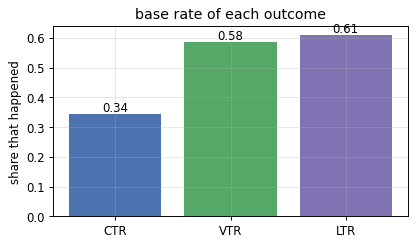

In [5]:
rates = [clicked.mean(), viewed.mean(), lead.mean()]
plt.figure(figsize=(5, 3))
plt.bar(HEADS, rates, color=HEAD_COLORS)
plt.ylabel("share that happened"); plt.title("base rate of each outcome")
for i, r in enumerate(rates): plt.text(i, r+0.01, f"{r:.2f}", ha="center")
plt.show()

## Step 6 · Does history drive all three outcomes?

Our claim is that `hist_affinity` matters for clicks, views, **and** leads. Let's check: for
each outcome, bucket impressions by history affinity and plot the outcome rate. All three
should slope **up** — proof there's real history signal to learn (and a preview of the
ablation in Step 12).

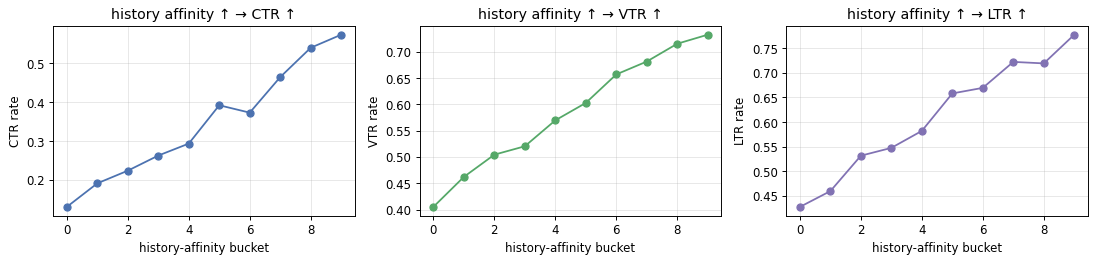

In [6]:
data["ha_bucket"] = pd.cut(data.hist_affinity, 10, labels=False)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, (col, name, color) in zip(ax, [("clicked","CTR",BLUE), ("viewed","VTR",GREEN), ("lead","LTR",PURPLE)]):
    a.plot(data.groupby("ha_bucket")[col].mean().values, "o-", color=color)
    a.set_title(f"history affinity ↑ → {name} ↑"); a.set_xlabel("history-affinity bucket"); a.set_ylabel(f"{name} rate")
plt.show()

## Step 7 · Train/test split

75% to learn from, 25% hidden for grading. We split the features and **all three** label
columns together so each impression keeps its three answers.

In [7]:
from sklearn.model_selection import train_test_split
idx = np.arange(N)
tr, te = train_test_split(idx, test_size=0.25, random_state=0)
Xtr_raw, Xte_raw = X[tr], X[te]
Ytr, Yte = Y[tr], Y[te]
true_test = data.loc[te, ["true_ctr", "true_vtr", "true_ltr"]].to_numpy()
print("train:", len(tr), "| test:", len(te))

train: 6000 | test: 2000


## Step 8 · Standardize the features

Features are on different scales (`position` up to 10, `hist_len` up to 50, others 0–1). We
rescale each to mean 0 / spread 1 using **train** statistics only, so no feature shouts over
the others and training is stable.

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(Xtr_raw)      # learn mean/std on TRAIN only
Xtr = scaler.transform(Xtr_raw)
Xte = scaler.transform(Xte_raw)
print("standardized. train feature means (should be ~0):", np.round(Xtr.mean(0), 2))

standardized. train feature means (should be ~0): [ 0.  0. -0.  0.  0.  0. -0.]


## Step 9 · Choose the model — why **shared-bottom multi-task** (in PyTorch)

**The model choice.** We must predict **three** related things (click, view, lead). Two
options:
- train **three separate models** — simple, but you learn the common patterns three times
  and pay to train/serve three networks;
- train **one shared-bottom multi-task model** — a single **shared body** (hidden layers)
  that learns the patterns common to all three tasks, then **three small heads**, one per
  task, that specialize.

We pick **shared-bottom** because the three outcomes overlap a lot (a relevant ad from a
favored category tends to do well on all of them), so sharing is cheaper *and* usually
more accurate (each task benefits from the others' data). It's the standard **starting
point** for multi-task ranking — lesson M7.3's **MMoE/PLE** are upgrades for when the
tasks start to *fight* each other.

**In PyTorch** we write it directly: a shared `body`, then a list of one-output `heads`.

In [9]:
import torch, torch.nn as nn
torch.manual_seed(0)

class SharedBottomRanker(nn.Module):
    def __init__(self, n_features, n_tasks=3):
        super().__init__()
        self.body  = nn.Sequential(               # the SHARED body: 7 -> 32 -> 16
            nn.Linear(n_features, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU())
        self.heads = nn.ModuleList([nn.Linear(16, 1) for _ in range(n_tasks)])  # one head per task
    def forward(self, x):
        z = self.body(x)                          # shared representation
        return torch.cat([h(z) for h in self.heads], dim=1)   # (batch, 3) logits: CTR, VTR, LTR

model = SharedBottomRanker(len(features))
print("model: 7 features -> shared (32, 16) -> 3 heads (CTR, VTR, LTR)")
print("total learnable numbers:", sum(p.numel() for p in model.parameters()))

model: 7 features -> shared (32, 16) -> 3 heads (CTR, VTR, LTR)
total learnable numbers: 835


## Step 10 · Train it — and log the learning

We run the PyTorch training loop ourselves so we can **log** it. Each **epoch**: predict,
measure the error on **all three heads** (summed **BCE** log loss), let autograd compute
gradients (`loss.backward()`), and step (`optimizer.step()`). We print the total and
per-head loss every 50 epochs and store them for a curve.

epoch |  total | CTR   VTR   LTR
    0 | 2.096 | 0.700 0.686 0.709
   50 | 1.597 | 0.510 0.524 0.563
  100 | 1.585 | 0.506 0.520 0.558
  150 | 1.577 | 0.504 0.518 0.555
  200 | 1.569 | 0.501 0.516 0.553
  250 | 1.559 | 0.497 0.512 0.550
done. final total loss: 1.551


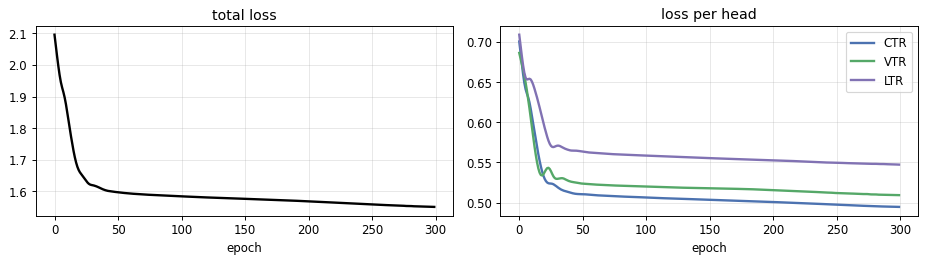

In [10]:
Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
Ytr_t = torch.tensor(Ytr, dtype=torch.float32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

total_hist, task_hist = [], []
print("epoch |  total | CTR   VTR   LTR")
for epoch in range(300):
    model.train(); optimizer.zero_grad()
    logits = model(Xtr_t)
    per_task = [loss_fn(logits[:, k], Ytr_t[:, k]) for k in range(3)]   # one loss per head
    loss = sum(per_task)                          # shared model optimizes all three at once
    loss.backward(); optimizer.step()
    total_hist.append(loss.item()); task_hist.append([l.item() for l in per_task])
    if epoch % 50 == 0:
        p = [l.item() for l in per_task]
        print(f"{epoch:5d} | {loss.item():.3f} | {p[0]:.3f} {p[1]:.3f} {p[2]:.3f}")
print("done. final total loss:", round(total_hist[-1], 3))

task_hist = np.array(task_hist)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(total_hist, color="black", lw=2); ax[0].set_title("total loss"); ax[0].set_xlabel("epoch")
for k, (name, c) in enumerate(zip(HEADS, HEAD_COLORS)):
    ax[1].plot(task_hist[:, k], color=c, lw=2, label=name)
ax[1].set_title("loss per head"); ax[1].set_xlabel("epoch"); ax[1].legend(); plt.show()

## Step 11 · Predict all three probabilities on unseen impressions

We switch the model to eval mode, predict under `torch.no_grad()` (no training), and apply
`torch.sigmoid` to turn each head's score into a probability: pCTR, pVTR, pLTR.

In [11]:
model.eval()
with torch.no_grad():
    proba = torch.sigmoid(model(torch.tensor(Xte, dtype=torch.float32))).numpy()  # (n_test, 3)
pred = pd.DataFrame(proba, columns=["pCTR", "pVTR", "pLTR"]).round(3)
pred["clicked"], pred["viewed"], pred["lead"] = Yte[:,0], Yte[:,1], Yte[:,2]
print("predictions on impressions the model never saw:")
print(pred.head(6).to_string(index=False))

predictions on impressions the model never saw:
 pCTR  pVTR  pLTR  clicked  viewed  lead
0.592 0.919 0.962        1       1     1
0.265 0.830 0.457        0       1     1
0.071 0.170 0.183        0       0     1
0.628 0.888 0.867        1       1     1
0.276 0.862 0.839        0       1     1
0.919 0.981 0.952        1       1     1


## Step 12 · Grade each head — AUC

AUC per head: *pick a positive and a negative example at random — AUC is the chance the
model scored the positive higher.* 0.5 = coin flip, 1.0 = perfect. We grade all three heads
and log them.

CTR AUC: 0.762
VTR AUC: 0.789
LTR AUC: 0.746


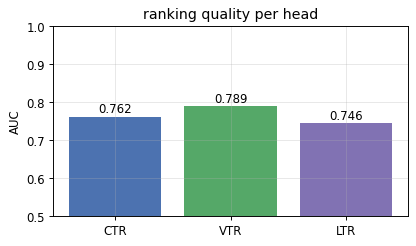

In [12]:
from sklearn.metrics import roc_auc_score
aucs = [roc_auc_score(Yte[:, k], proba[:, k]) for k in range(3)]
for name, a in zip(HEADS, aucs): print(f"{name} AUC: {a:.3f}")
plt.figure(figsize=(5, 3))
plt.bar(HEADS, aucs, color=HEAD_COLORS); plt.ylim(0.5, 1.0); plt.ylabel("AUC")
for i, a in enumerate(aucs): plt.text(i, a+0.01, f"{a:.3f}", ha="center")
plt.title("ranking quality per head"); plt.show()

## Step 13 · Are the three probabilities honest? (calibration)

Each head should be calibrated: when it says 0.3, about 30% should really happen. We draw a
reliability curve per head; on the diagonal = honest. Calibration matters because the next
step *multiplies* these probabilities, so their scale must be truthful.

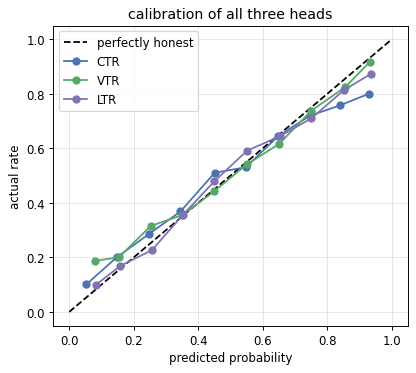

In [13]:
from sklearn.calibration import calibration_curve
plt.figure(figsize=(5, 4.5))
plt.plot([0,1],[0,1], "k--", label="perfectly honest")
for k, (name, color) in enumerate(zip(HEADS, HEAD_COLORS)):
    frac, mean = calibration_curve(Yte[:, k], proba[:, k], n_bins=10)
    plt.plot(mean, frac, "o-", color=color, label=name)
plt.xlabel("predicted probability"); plt.ylabel("actual rate")
plt.title("calibration of all three heads"); plt.legend(); plt.show()

## Step 14 · Combine the heads into ONE serving score (multi-objective)

A real system must pick ONE ad, so it blends the heads into a single **serving score** with
business weights that say how much each outcome is worth:

`score = w_click · pCTR + w_view · pVTR + w_lead · pLTR`

Leads are worth the most here, so they get the biggest weight. Because each head is a
calibrated probability, the terms are on a comparable scale and the weights are a genuine
business choice (not an accidental unit mismatch). This is the multi-objective head from
lesson M7.3.

In [14]:
w_click, w_view, w_lead = 0.3, 0.2, 0.5     # business weights (leads valued most)
serving_score = w_click*proba[:,0] + w_view*proba[:,1] + w_lead*proba[:,2]
print("serving score = "
      f"{w_click}·pCTR + {w_view}·pVTR + {w_lead}·pLTR")
print("example scores:", np.round(serving_score[:5], 3))

# show how the same impression can rank differently by objective
top_click = np.argsort(-proba[:,0])[:1][0]
top_lead  = np.argsort(-proba[:,2])[:1][0]
print(f"\nhighest-pCTR impression: pCTR={proba[top_click,0]:.2f} pLTR={proba[top_click,2]:.2f}")
print(f"highest-pLTR impression: pCTR={proba[top_lead,0]:.2f}  pLTR={proba[top_lead,2]:.2f}")
print("-> optimizing clicks vs leads can pick different ads; the weights decide.")

serving score = 0.3·pCTR + 0.2·pVTR + 0.5·pLTR
example scores: [0.842 0.474 0.147 0.799 0.675]

highest-pCTR impression: pCTR=0.95 pLTR=0.98
highest-pLTR impression: pCTR=0.64  pLTR=0.98
-> optimizing clicks vs leads can pick different ads; the weights decide.


## Step 15 · Rank the ads by the combined score

Sort impressions by the serving score, highest first — this is what would be shown at the
top. We display the top few with all three predicted probabilities so you can see the blend
at work.

In [15]:
order = np.argsort(-serving_score)
top = pd.DataFrame(proba[order[:8]], columns=["pCTR","pVTR","pLTR"]).round(3)
top["serving_score"] = serving_score[order[:8]].round(3)
print("top-8 ads by combined serving score:")
print(top.to_string(index=False))

top-8 ads by combined serving score:
 pCTR  pVTR  pLTR  serving_score
0.950 0.963 0.981          0.968
0.942 0.966 0.984          0.968
0.949 0.973 0.964          0.962
0.926 0.957 0.973          0.956
0.893 0.968 0.981          0.952
0.949 0.951 0.951          0.950
0.936 0.945 0.957          0.948
0.919 0.981 0.952          0.948


## Step 16 · Does history actually help? (an ablation)

The honest test: **remove** the two history features, retrain the same model, and compare.
If history carries real signal, every head's AUC should **drop** without it. This is how you
justify a feature's cost in a real system.

head   with history   without    drop
CTR           0.762     0.705   0.058
VTR           0.789     0.750   0.039
LTR           0.746     0.715   0.030


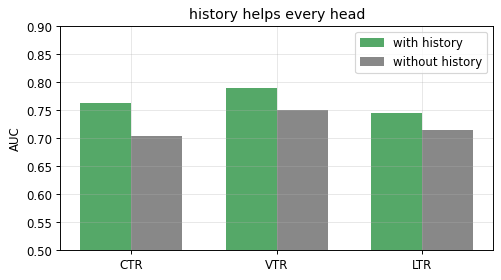

In [16]:
# drop the two history features (columns 5, 6), standardize, retrain the SAME architecture in torch
Xtr_nh_raw, Xte_nh_raw = X[tr][:, :5], X[te][:, :5]
sc_nh = StandardScaler().fit(Xtr_nh_raw)
Xtr_nh = torch.tensor(sc_nh.transform(Xtr_nh_raw), dtype=torch.float32)
Xte_nh = torch.tensor(sc_nh.transform(Xte_nh_raw), dtype=torch.float32)

torch.manual_seed(0)
model_nh = SharedBottomRanker(5)                       # same model, 5 features (no history)
opt_nh = torch.optim.Adam(model_nh.parameters(), lr=0.01)
for epoch in range(300):
    model_nh.train(); opt_nh.zero_grad()
    lg = model_nh(Xtr_nh)
    loss = sum(loss_fn(lg[:, k], Ytr_t[:, k]) for k in range(3))
    loss.backward(); opt_nh.step()
model_nh.eval()
with torch.no_grad():
    proba_nh = torch.sigmoid(model_nh(Xte_nh)).numpy()
aucs_nh = [roc_auc_score(Yte[:,k], proba_nh[:,k]) for k in range(3)]

print(f"{'head':<5} {'with history':>13} {'without':>9} {'drop':>7}")
for name, a, anh in zip(HEADS, aucs, aucs_nh):
    print(f"{name:<5} {a:>13.3f} {anh:>9.3f} {a-anh:>7.3f}")

x = np.arange(3); wdt = 0.35
plt.figure(figsize=(6, 3.4))
plt.bar(x-wdt/2, aucs, wdt, color=GREEN, label="with history")
plt.bar(x+wdt/2, aucs_nh, wdt, color=GRAY, label="without history")
plt.xticks(x, HEADS); plt.ylim(0.5, 0.9); plt.ylabel("AUC")
plt.title("history helps every head"); plt.legend(); plt.show()

## Step 17 · Proof — predicted vs actual, per head

The closing check. For each head, sort impressions into 10 groups by predicted probability
and compare the **predicted** rate (bars) to the **actual** rate (dots). Matching, low to
high, means the model's probabilities track reality for all three tasks.

AUCs — CTR 0.762, VTR 0.789, LTR 0.746. All three heads track reality.


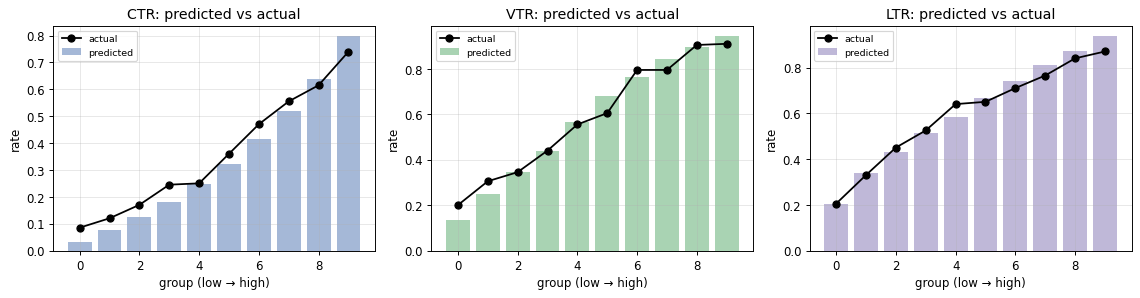

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
for k, (name, color) in enumerate(zip(HEADS, HEAD_COLORS)):
    dec = pd.qcut(proba[:, k], 10, labels=False, duplicates="drop")
    gdf = pd.DataFrame({"d": dec, "pred": proba[:, k], "act": Yte[:, k]}).groupby("d").mean()
    ax[k].bar(gdf.index, gdf.pred, color=color, alpha=.5, label="predicted")
    ax[k].plot(gdf.index, gdf.act, "o-", color="black", label="actual")
    ax[k].set_title(f"{name}: predicted vs actual"); ax[k].set_xlabel("group (low → high)")
    ax[k].set_ylabel("rate"); ax[k].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("AUCs — CTR {:.3f}, VTR {:.3f}, LTR {:.3f}. All three heads track reality.".format(*aucs))

---
## What you just built — a real ranker's shape

1. **Data** with static + **history** features and **three** outcomes (click / view / lead).
2. One **shared-bottom multi-task** model → three calibrated heads (**pCTR, pVTR, pLTR**).
3. Watched it **train** (loss curve), graded each head (**AUC**), checked **calibration**.
4. Blended the heads into one **serving score** with business weights (multi-objective).
5. **Proved history helps** with an ablation, and that each head **tracks reality**.

### How this maps to lesson M7.3 (the architecture flowchart)
- The single history number is a precomputed **DIN**-style candidate-aware feature; richer
  systems learn it with attention over the raw history (**DIN → DIEN → BST → SIM**).
- Our three-head network is the **shared-bottom** tower; **MMoE** and **PLE** are upgrades
  that reduce the tasks fighting each other ("negative transfer").
- The `serving_score = Σ wᵢ·pᵢ` blend is the **multi-objective head**; in ads it's combined
  with the **bid** (`pCTR × bid`) in the auction.
- Calibration (Step 13) is exactly what module **M8** teaches you to measure and repair.

You now have the end-to-end mental model of a production ranker. 🎯